In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, accuracy_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure GPU memory growth
try:
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("Using GPU:", physical_devices[0])
    else:
        print("Using CPU")
except RuntimeError as e:
    print("Warning: Could not set GPU memory growth:", str(e))

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Define paths
data_dir = r"D:\SCI\DAIC-WOZ\code"
csv_files = ["goemotions_1.csv", "goemotions_2.csv", "goemotions_3.csv"]
model_path = os.path.join(data_dir, "goemotions_bert_model")
output_dir = data_dir
os.makedirs(output_dir, exist_ok=True)

# Verify file existence
for file in csv_files:
    file_path = os.path.join(data_dir, file)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}. Download from: https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/{file}")

# Load and concatenate CSV files
dataframes = [pd.read_csv(os.path.join(data_dir, file)) for file in csv_files]
data = pd.concat(dataframes, ignore_index=True)

# Check for duplicates
print("Duplicate IDs before deduplication:", data['id'].duplicated().sum())

# Define emotions
emotion_columns = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]
depression_emotions = ['sadness', 'grief', 'remorse', 'disappointment', 'disapproval']
positive_emotions = ['admiration', 'amusement', 'approval', 'caring', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']

# === 12 个中间情绪（剩余部分）===
neutral_emotions = [
    'anger', 'annoyance', 'confusion', 'curiosity', 'desire',
    'disgust', 'embarrassment', 'fear', 'nervousness', 'realization', 'surprise', 'neutral'
]

# Aggregate annotations per id
agg_dict = {col: 'sum' for col in emotion_columns}
agg_dict.update({
    'text': 'first', 'author': 'first', 'subreddit': 'first', 'link_id': 'first',
    'parent_id': 'first', 'created_utc': 'first', 'rater_id': 'first', 'example_very_unclear': 'first'
})
data = data.groupby('id').agg(agg_dict).reset_index()

# Convert summed labels to binary
for col in emotion_columns:
    data[col] = (data[col] >= 1).astype(int)

# Filter out unclear examples
data = data[data['example_very_unclear'] == False]

# Rater agreement filter for rare emotions
rare_emotions = ['grief', 'pride', 'relief', 'nervousness']
data['rare_sum'] = data[rare_emotions].sum(axis=1)
data = data[(data[emotion_columns].sum(axis=1) >= 1) | (data['rare_sum'] >= 2)]
data = data.drop(columns=['rare_sum'])

# === 不限制数据总量，去掉 expected_size 限制 ===
# expected_size = 54263  # 注释掉，不再截断

# Aggregate per author
author_data = data.groupby('author').agg({
    **{col: 'sum' for col in emotion_columns},
    'text': lambda x: ' '.join(x),
    'subreddit': 'first',
    'id': 'count'
}).rename(columns={'id': 'comment_count'}).reset_index()

# Filter authors with >=2 comments
author_data = author_data[author_data['comment_count'] >= 2]
print(f"Filtered to authors with >=2 comments: {len(author_data)}")

# === 新指标：DEP = depression / (depression + positive + neutral) ===
# 向量化计算，高效且安全
author_data['DEP'] = (
    author_data[depression_emotions].sum(axis=1) /
    (author_data[depression_emotions].sum(axis=1) +
     author_data[positive_emotions].sum(axis=1) +
     author_data[neutral_emotions].sum(axis=1))
)

# Create ground-truth depression labels
prevalence = 0.1102
threshold = author_data['DEP'].quantile(1 - prevalence)
author_data['depression_true'] = (author_data['DEP'] >= threshold).astype(int)
print(f"Depression threshold (for {prevalence*100:.2f}% prevalence): {threshold:.4f}")
print(f"True Positive Rate (Prevalence): {author_data['depression_true'].mean():.4f}")

# === Data Distribution Analysis ===
print("\n=== Data Distribution Analysis ===")
print(f"Number of unique authors: {len(author_data)}")
print(f"Comment count distribution:")
print(author_data['comment_count'].describe())
plt.figure(figsize=(8, 6))
author_data['comment_count'].hist(bins=20, color='#1f77b4')
plt.title('Distribution of Comments per Author')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'comment_count_distribution.png'))
plt.close()

print("\nEmotion Prevalence (True Labels, per-author):")
emotion_prevalence = (author_data[emotion_columns] > 0).mean().sort_values(ascending=False)
print(emotion_prevalence)
# === 替换原来的 emotion_prevalence_author.png 绘图代码 ===

print("\nEmotion Prevalence (True Labels, per-author):")
emotion_prevalence = (author_data[emotion_columns] > 0).mean().sort_values(ascending=False)
print(emotion_prevalence)

# === 替换原来的 emotion_prevalence_author 柱状图代码为极坐标环形图 ===
print("\nEmotion Prevalence (True Labels, per-author) - Generating Circular Bar Plot...")
emotion_prevalence = (author_data[emotion_columns] > 0).mean().sort_values(ascending=False)

# 1. 定义三大情绪组及其颜色
depression_emotions = ['sadness', 'grief', 'remorse', 'disappointment', 'disapproval']
positive_emotions = ['admiration', 'amusement', 'approval', 'caring', 'excitement', 
                     'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']
neutral_emotions = [e for e in emotion_columns if e not in depression_emotions + positive_emotions]

# 颜色映射（参考你图片中的渐变美感）
color_map = {}
for emo in depression_emotions:
    color_map[emo] = '#d73027'   # 红系主色
for emo in positive_emotions:
    color_map[emo] = '#1a9850'   # 绿系主色
for emo in neutral_emotions:
    color_map[emo] = '#91bfdb'   # 蓝灰系

# 渐变效果（可选，更美观）
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import seaborn as sns

# 排序后的情绪顺序（从高到低）
emotions_sorted = emotion_prevalence.index.tolist()
values = emotion_prevalence.values

# 为每个情绪分配颜色（保持排序一致）
colors = [color_map[emo] for emo in emotions_sorted]

# === 绘制极坐标环形柱状图 ===
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, polar=True)

# 参数设置
bar_width = 0.2
max_val = values.max()
padding = 0.08  # 柱子与标签间距

# 绘制柱子
angles = np.linspace(0, 2*np.pi, len(emotions_sorted), endpoint=False).tolist()
angles += angles[:1]  # 闭合
values = np.append(values, values[0])  # 闭合

bars = ax.bar(angles, values, width=bar_width, color=colors, edgecolor='white', linewidth=1.2, alpha=0.95)

# 设置半径范围
ax.set_ylim(0, max_val + padding)

# 隐藏网格和刻度
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

# 添加标签（在柱子外侧）
for angle, val, label, color in zip(angles, values, emotions_sorted + [emotions_sorted[0]], colors):
    # 旋转角度对齐
    rotation = np.rad2deg(angle)
    alignment = "center"
    if rotation > 90 and rotation < 270:
        rotation += 180
        alignment = "center"

    # 标签位置
    radius = val + padding/2
    ax.text(angle, radius, label.replace('_', ' ').title(), 
            ha='center', va='center', rotation=rotation-90 if (rotation>90 and rotation<270) else rotation-90,
            rotation_mode='anchor', fontsize=11, fontweight='medium', color='black')

# 添加比例值（在柱子顶部）
for bar, val in zip(bars, emotion_prevalence.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + padding/3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# === 添加三大情绪分区背景色（半透明扇区）===
def add_sector(ax, start_angle, end_angle, color, alpha=0.08):
    wedges = []
    for i in range(len(angles)-1):
        if start_angle <= angles[i] < end_angle:
            wedge = ax.bar(angles[i], max_val*1.4, width=bar_width+0.05, color=color, alpha=alpha, edgecolor='none')
            wedges.append(wedge)
    return wedges

# 计算每个大类的角度范围
emo_to_angle = dict(zip(emotions_sorted, angles[:-1]))

# Depression 区域（红色背景）
dep_angles = [emo_to_angle[e] for e in depression_emotions if e in emo_to_angle]
if dep_angles:
    add_sector(ax, min(dep_angles), max(dep_angles) + bar_width, '#d73027', alpha=0.12)

# Positive 区域（绿色背景）
pos_angles = [emo_to_angle[e] for e in positive_emotions if e in emo_to_angle]
if pos_angles:
    add_sector(ax, min(pos_angles), max(pos_angles) + bar_width, '#1a9850', alpha=0.12)

# Neutral 区域（蓝色背景）
neu_angles = [emo_to_angle[e] for e in neutral_emotions if e in emo_to_angle]
if neu_angles:
    add_sector(ax, min(neu_angles), max(neu_angles) + bar_width, '#91bfdb', alpha=0.08)

# 图例（三大类）
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#d73027', lw=8, label='Depression-Related Emotions'),
    Line2D([0], [0], color='#1a9850', lw=8, label='Positive Emotions'),
    Line2D([0], [0], color='#91bfdb', lw=8, label='Neutral / Other Emotions'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=1, fontsize=13, frameon=False)

# 标题
plt.title('Emotion Prevalence Across Authors\n(Proportion of authors expressing each emotion at least once)',
          fontsize=18, fontweight='bold', pad=40)

# 保存
output_path = os.path.join(output_dir, 'emotion_prevalence_author_circular.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print(f"极坐标情绪分布图已保存 → {output_path}")

print("\nDEP Distribution:")
print(author_data['DEP'].describe())
plt.figure(figsize=(8, 6))
author_data['DEP'].hist(bins=50, color='blue', range=(0, 1))
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.title('Distribution of Depression Emotion Proportion (DEP)')
plt.xlabel('DEP')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'dep_distribution_author.png'))
plt.close()

print("\nTop 10 Subreddits by Author Count:")
subreddit_counts = author_data['subreddit'].value_counts().head(10)
print(subreddit_counts)
plt.figure(figsize=(12, 6))
subreddit_counts.plot(kind='bar', color='#1f77b4')
plt.title('Top 10 Subreddits by Author Count')
plt.xlabel('Subreddit')
plt.ylabel('Number of Authors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'subreddit_distribution_author.png'))
plt.close()

# Split data into train and validation sets
train_data, val_data = train_test_split(author_data, test_size=0.2, random_state=42, stratify=author_data['depression_true'])

# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained(model_path)

# Tokenize texts
max_length = 100
def tokenize_texts(texts):
    encodings = tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encodings

train_encodings = tokenize_texts(train_data['text'])
val_encodings = tokenize_texts(val_data['text'])

# Extract TF-IDF features
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
tfidf.fit(author_data['text'])
train_tfidf = tfidf.transform(train_data['text']).toarray()
val_tfidf = tfidf.transform(val_data['text']).toarray()

# Subreddit embeddings
subreddit_vocab = author_data['subreddit'].unique()
subreddit_to_idx = {sub: idx for idx, sub in enumerate(subreddit_vocab)}
train_subreddit_idx = train_data['subreddit'].map(subreddit_to_idx).values
val_subreddit_idx = val_data['subreddit'].map(subreddit_to_idx).values

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask'],
        'token_type_ids': train_encodings.get('token_type_ids', tf.zeros_like(train_encodings['input_ids'])),
        'tfidf': train_tfidf,
        'subreddit_idx': train_subreddit_idx
    },
    train_data['depression_true'].values
)).shuffle(1000).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': val_encodings['input_ids'],
        'attention_mask': val_encodings['attention_mask'],
        'token_type_ids': val_encodings.get('token_type_ids', tf.zeros_like(val_encodings['input_ids'])),
        'tfidf': val_tfidf,
        'subreddit_idx': val_subreddit_idx
    },
    val_data['depression_true'].values
)).batch(16)

# Define custom model
class DepressionModel(tf.keras.Model):
    def __init__(self, bert_model, num_subreddits, tfidf_dim):
        super(DepressionModel, self).__init__()
        self.bert = bert_model
        self.subreddit_embedding = tf.keras.layers.Embedding(num_subreddits, 16)
        self.tfidf_dense = tf.keras.layers.Dense(64, activation='relu')
        self.concat = tf.keras.layers.Concatenate()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dropout = tf.keras.layers.Dropout(0.3)
        self.dense2 = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs, training=False):
        bert_output = self.bert(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            token_type_ids=inputs['token_type_ids'],
            training=training
        ).pooler_output
        subreddit_emb = self.subreddit_embedding(inputs['subreddit_idx'])
        tfidf_out = self.tfidf_dense(inputs['tfidf'])
        combined = self.concat([bert_output, subreddit_emb, tfidf_out])
        x = self.dense1(combined)
        x = self.dropout(x, training=training)
        return self.dense2(x)

# Initialize model
bert_model = TFBertForSequenceClassification.from_pretrained(model_path, output_attentions=False, output_hidden_states=False)
model = DepressionModel(bert_model.bert, len(subreddit_vocab), 1000)

# Class weights
class_weights = {0: 1.0, 1: 1.0 / prevalence}

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3,
    class_weight=class_weights
)

# Optimize threshold
val_predictions = model.predict(val_dataset)
val_probs = val_predictions.flatten()
val_true = val_data['depression_true'].values
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []
for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    f1 = f1_score(val_true, preds)
    f1_scores.append(f1)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_threshold:.2f}")

# Predict on full dataset
full_encodings = tokenize_texts(author_data['text'])
full_tfidf = tfidf.transform(author_data['text']).toarray()
full_subreddit_idx = author_data['subreddit'].map(subreddit_to_idx).values
full_dataset = tf.data.Dataset.from_tensor_slices({
    'input_ids': full_encodings['input_ids'],
    'attention_mask': full_encodings['attention_mask'],
    'token_type_ids': full_encodings.get('token_type_ids', tf.zeros_like(full_encodings['input_ids'])),
    'tfidf': full_tfidf,
    'subreddit_idx': full_subreddit_idx
}).batch(16)

predictions = model.predict(full_dataset).flatten()
pred_df = pd.DataFrame({
    'author': author_data['author'],
    'text': author_data['text'],
    'subreddit': author_data['subreddit'],
    'depression_pred': (predictions >= optimal_threshold).astype(int),
    'depression_prob': predictions
})

# Evaluate
true_labels = author_data['depression_true'].values
pred_labels = pred_df['depression_pred'].values
f1 = f1_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels)
recall = recall_score(true_labels, pred_labels)
accuracy = accuracy_score(true_labels, pred_labels)
auc = roc_auc_score(true_labels, pred_df['depression_prob'])
cm = confusion_matrix(true_labels, pred_labels)
tn, fp, fn, tp = cm.ravel()

print("\nDepression Prediction Performance (Per Author):")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Predicted Positive Rate: {pred_df['depression_pred'].mean():.4f}")
print("\nConfusion Matrix:")
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Visualizations
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Depressed', 'Depressed'],
            yticklabels=['Not Depressed', 'Depressed'])
plt.title('Confusion Matrix for Depression Prediction (Per Author)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(os.path.join(output_dir, 'confusion_matrix_improved_author.png'))
plt.close()

fpr, tpr, _ = roc_curve(true_labels, pred_df['depression_prob'])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Depression Prediction (Per Author)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'roc_curve_improved_author.png'))
plt.close()

plt.figure(figsize=(8, 6))
plt.hist(pred_df['depression_prob'], bins=50, alpha=0.7, color='blue', range=(0, 1))
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Threshold = {optimal_threshold:.2f}')
plt.title('Distribution of Depression Probabilities (Per Author)')
plt.xlabel('Depression Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'depression_prob_histogram_improved_author.png'))
plt.close()

# Save predictions
pred_df.to_csv(os.path.join(output_dir, 'depression_predictions_improved_author.csv'), index=False)
print(f"\nPredictions saved to: {os.path.join(output_dir, 'depression_predictions_improved_author.csv')}")
print(f"Plots saved to:")
print(f"- {os.path.join(output_dir, 'comment_count_distribution.png')}")
print(f"- {os.path.join(output_dir, 'emotion_prevalence_author.png')}")
print(f"- {os.path.join(output_dir, 'dep_distribution_author.png')}")
print(f"- {os.path.join(output_dir, 'subreddit_distribution_author.png')}")
print(f"- {os.path.join(output_dir, 'confusion_matrix_improved_author.png')}")
print(f"- {os.path.join(output_dir, 'roc_curve_improved_author.png')}")
print(f"- {os.path.join(output_dir, 'depression_prob_histogram_improved_author.png')}")
# ==============================
#  完整可执行脚本：长度偏差分析 + 长度匹配消融实验（输出完整指标）
#  直接复制运行即可（只需确保前面的 author_data、model、tfidf、subreddit_to_idx、optimal_threshold 已存在）
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import os
import tensorflow as tf

# ------------------- 1. 计算长度特征 -------------------
print("\n=== 1. 计算文本长度特征 ===")
author_data['total_chars'] = author_data['text'].str.len()
author_data['total_words'] = author_data['text'].str.split().apply(len)
author_data['avg_chars_per_comment'] = author_data['total_chars'] / author_data['comment_count']
author_data['avg_words_per_comment'] = author_data['total_words'] / author_data['comment_count']

# ------------------- 2. 绘制四面板图 -------------------
print("=== 2. 绘制四面板图 ===")
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Length Bias Analysis in Depression Prediction', fontsize=16, fontweight='bold')

# (0,0) 总字符分布（log scale）
axes[0,0].hist(author_data['total_chars'], bins=120, color='#1f77b4', alpha=0.8, edgecolor='white')
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel('Total Characters per Author')
axes[0,0].set_ylabel('Frequency (Log Scale)')
axes[0,0].set_title('Distribution of Total Text Length')
max_idx = author_data['total_chars'].idxmax()
axes[0,0].axvline(author_data.loc[max_idx, 'total_chars'], color='red', linestyle='--', linewidth=2)
axes[0,0].text(author_data.loc[max_idx, 'total_chars']*0.92, 1e4,
               f"Max = {author_data.loc[max_idx, 'total_chars']:,}\n({author_data.loc[max_idx, 'comment_count']} comments)",
               color='red', ha='right', fontsize=10)

# (0,1) 箱线图
sns.boxplot(y='total_chars', data=author_data, ax=axes[0,1], color='lightcoral', width=0.4)
axes[0,1].set_ylabel('Total Characters')
axes[0,1].set_title('Boxplot of Total Text Length')

# (1,0) 抑郁 vs 非抑郁（使用 hue 兼容新版 seaborn）
sns.boxplot(x='depression_true', y='total_chars', data=author_data, ax=axes[1,0],
            hue='depression_true', palette={0:'#4c72b0', 1:'#dd8452'}, legend=False)
axes[1,0].set_xticklabels(['Non-Depressed', 'Depressed'])
axes[1,0].set_xlabel('Ground Truth Label')
axes[1,0].set_ylabel('Total Characters')
axes[1,0].set_title('Text Length by Depression Label')

# (1,1) DEP vs 长度（LOESS）
sns.scatterplot(x='total_chars', y='DEP', data=author_data, alpha=0.5, ax=axes[1,1], color='gray', s=30)
sns.regplot(x='total_chars', y='DEP', data=author_data, scatter=False,
            lowess=True, line_kws={'color':'red','linewidth':2}, ax=axes[1,1])
axes[1,1].set_xlabel('Total Characters')
axes[1,1].set_ylabel('DEP Score')
axes[1,1].set_title('DEP Score vs Total Text Length (LOESS)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'length_bias_analysis.png'), dpi=300, bbox_inches='tight')
plt.close()
print("图表已保存 → length_bias_analysis.png")

# ------------------- 3. 统计检验 -------------------
print("\n=== 3. 统计检验 ===")
dep_chars = author_data[author_data['depression_true']==1]['total_chars']
non_chars = author_data[author_data['depression_true']==0]['total_chars']

u_stat, p_val = mannwhitneyu(dep_chars, non_chars, alternative='two-sided')
n1, n2 = len(dep_chars), len(non_chars)
cliffs_delta = (2 * u_stat / (n1 * n2)) - 1 if p_val < 1 else 0

print(f"抑郁组中位数字符数       : {dep_chars.median():.0f}")
print(f"非抑郁组中位数字符数     : {non_chars.median():.0f}")
print(f"Mann-Whitney U p-value   : {p_val:.6f}")
print(f"Cliff's delta            : {cliffs_delta:+.4f}")

# ------------------- 4. 构建长度完全匹配的平衡测试集 -------------------
print("\n=== 4. 构建长度匹配平衡测试集（1:1） ===")
dep_df = author_data[author_data['depression_true'] == 1].copy()
non_df = author_data[author_data['depression_true'] == 0].copy()

# 使用最近邻匹配（距离阈值 8000，可自行调小）
nn = NearestNeighbors(n_neighbors=1)
nn.fit(dep_df[['total_chars']].values)
distances, indices = nn.kneighbors(non_df[['total_chars']].values)

threshold = 8000
mask = distances.flatten() <= threshold
matched_non = non_df.iloc[mask]
matched_dep = dep_df.iloc[indices.flatten()[mask]]

# 取两者较小的那一组做最终样本（保证 1:1）
min_size = min(len(matched_dep), len(matched_non))
matched_dep = matched_dep.sample(n=min_size, random_state=42)
matched_non = matched_non.sample(n=min_size, random_state=42)

matched_test = pd.concat([matched_dep, matched_non], ignore_index=True)
matched_test = matched_test.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"成功构建！样本量 = {len(matched_test)} (抑郁 {matched_test['depression_true'].sum()} | 非抑郁 {len(matched_test)//2})")
print(f"长度中位数匹配情况 → 抑郁: {matched_dep['total_chars'].median():.0f}  vs  非抑郁: {matched_non['total_chars'].median():.0f}")

# ------------------- 5. 模型预测（完整指标） -------------------
print("\n=== 5. 在长度匹配测试集上评估原始模型（完整指标） ===")

# Tokenize
test_enc = tokenize_texts(matched_test['text'])
test_tfidf = tfidf.transform(matched_test['text']).toarray()
test_sub_idx = matched_test['subreddit'].map(subreddit_to_idx)
test_sub_idx = test_sub_idx.fillna(0).astype(int).values

test_dataset = tf.data.Dataset.from_tensor_slices({
    'input_ids': test_enc['input_ids'],
    'attention_mask': test_enc['attention_mask'],
    'token_type_ids': test_enc.get('token_type_ids', tf.zeros_like(test_enc['input_ids'])),
    'tfidf': test_tfidf,
    'subreddit_idx': test_sub_idx
}).batch(16)

probs = model.predict(test_dataset, verbose=0).flatten()
preds = (probs >= optimal_threshold).astype(int)
true_y = matched_test['depression_true'].values

# 完整指标
acc  = accuracy_score(true_y, preds)
prec = precision_score(true_y, preds)
rec  = recall_score(true_y, preds)
f1   = f1_score(true_y, preds)
auc  = roc_auc_score(true_y, probs)
tn, fp, fn, tp = confusion_matrix(true_y, preds).ravel()

print("\n" + "="*70)
print("                     性能对比（Length Bias Ablation）")
print("="*70)
print(f"{'Setting':<25} {'Samples':>8} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>8} {'AUC':>8}")
print("-"*70)
print(f"{'Full Dataset':<25} {len(author_data):8} {accuracy_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)):.4f} "
      f"{precision_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)):.4f} "
      f"{recall_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)):.4f} "
      f"{f1:.4f} {auc:.4f}")
print(f"{'Length-Matched Test':<25} {len(matched_test):8} {acc:.4f} {prec:.4f} {rec:.4f} {f1:.4f} {auc:.4f}")
print("-"*70)
print(f"Confusion Matrix on Length-Matched Test → TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(classification_report(true_y, preds, target_names=['Non-Depressed', 'Depressed']))

# ------------------- 6. 保存结果 -------------------
result_df = pd.DataFrame({
    'Setting': ['Full Dataset', 'Length-Matched Test'],
    'Samples': [len(author_data), len(matched_test)],
    'Accuracy': [accuracy_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)), acc],
    'Precision': [precision_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)), prec],
    'Recall': [recall_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)), rec],
    'F1': [f1_score(author_data['depression_true'], (model.predict(full_dataset).flatten() >= optimal_threshold).astype(int)), f1],
    'AUC': [roc_auc_score(author_data['depression_true'], model.predict(full_dataset).flatten()), auc]
})
result_df.to_csv(os.path.join(output_dir, 'length_bias_ablation_complete.csv'), index=False)
print("\n所有结果已保存！")
print("→ 图片: length_bias_analysis.png")
print("→ 表格: length_bias_ablation_complete.csv")

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Duplicate IDs before deduplication: 153214
Filtered to authors with >=2 comments: 5182
Depression threshold (for 11.02% prevalence): 0.3333
True Positive Rate (Prevalence): 0.1223

=== Data Distribution Analysis ===
Number of unique authors: 5182
Comment count distribution:
count    5182.000000
mean        2.664608
std        14.571504
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max      1048.000000
Name: comment_count, dtype: float64

Emotion Prevalence (True Labels, per-author):
neutral           0.829988
approval          0.458124
annoyance         0.364724
admiration        0.338865
disapproval       0.322269
realization       0.269780
disappointment    0.267657
curiosity         0.241027
optimism          0.238711
anger             0.227132
joy               0.206098
confusion         0.200695
amusement         0.196256
gratitude         0.179853
sadness           0.

Some layers from the model checkpoint at D:\SCI\DAIC-WOZ\code\goemotions_bert_model were not used when initializing TFBertForSequenceClassification: ['dropout_227']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at D:\SCI\DAIC-WOZ\code\goemotions_bert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


Epoch 1/3
260/260 [==============================] - 88s 263ms/step - loss: 1.1350 - accuracy: 0.6376 - val_loss: 0.6431 - val_accuracy: 0.6644
Epoch 2/3
260/260 [==============================] - 63s 241ms/step - loss: 0.6669 - accuracy: 0.8362 - val_loss: 0.5446 - val_accuracy: 0.7358
Epoch 3/3
65/65 [==============================] - 9s 85ms/step
Optimal threshold: 0.15
324/324 [==============================] - 30s 80ms/step

Depression Prediction Performance (Per Author):
F1 Score: 0.7573
Precision: 0.6363
Recall: 0.9353
Accuracy: 0.9267
AUC: 0.9663
Predicted Positive Rate: 0.1799

Confusion Matrix:
True Positives (TP): 593
True Negatives (TN): 4209
False Positives (FP): 339
False Negatives (FN): 41

Predictions saved to: D:\SCI\DAIC-WOZ\code\depression_predictions_improved_author.csv
Plots saved to:
- D:\SCI\DAIC-WOZ\code\comment_count_distribution.png
- D:\SCI\DAIC-WOZ\code\emotion_prevalence_author.png
- D:\SCI\DAIC-WOZ\code\dep_distribution_author.png
- D:\SCI\DAIC-WOZ\code\su

C:\Users\47653\AppData\Local\Temp\ipykernel_21056\774055788.py:547: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1,0].set_xticklabels(['Non-Depressed', 'Depressed'])


图表已保存 → length_bias_analysis.png

=== 3. 统计检验 ===
抑郁组中位数字符数       : 146
非抑郁组中位数字符数     : 158
Mann-Whitney U p-value   : 0.000342
Cliff's delta            : -0.0877

=== 4. 构建长度匹配平衡测试集（1:1） ===
成功构建！样本量 = 9094 (抑郁 4547 | 非抑郁 4547)
长度中位数匹配情况 → 抑郁: 158  vs  非抑郁: 158

=== 5. 在长度匹配测试集上评估原始模型（完整指标） ===

                     性能对比（Length Bias Ablation）
Setting                    Samples    Acc   Prec    Rec       F1      AUC
----------------------------------------------------------------------
324/324 [==============================] - 27s 85ms/step
Full Dataset                  5182 0.9267 0.6363 0.9353 0.9302 0.9663
Length-Matched Test           9094 0.9298 0.9261 0.9342 0.9302 0.9663
----------------------------------------------------------------------
Confusion Matrix on Length-Matched Test → TP=4248, FP=339, FN=299, TN=4208
               precision    recall  f1-score   support

Non-Depressed       0.93      0.93      0.93      4547
    Depressed       0.93      0.93      0.93      4547

In [38]:
import pandas as pd
import numpy as np
import os

# ================= 配置路径 =================
data_dir = r"D:\SCI\DAIC-WOZ\code"
csv_files = ["goemotions_1.csv", "goemotions_2.csv", "goemotions_3.csv"]
output_file = os.path.join(data_dir, "polar_plot_data.csv")

# ================= 1. 数据准备 =================
print("正在加载和处理真实数据...")
try:
    dataframes = [pd.read_csv(os.path.join(data_dir, file)) for file in csv_files]
    data = pd.concat(dataframes, ignore_index=True)
    
    emotion_columns = [
        'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
        'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
        'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
        'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
        'relief', 'remorse', 'sadness', 'surprise', 'neutral'
    ]
    agg_dict = {col: 'sum' for col in emotion_columns}
    agg_dict.update({'author': 'first', 'example_very_unclear': 'first'})
    data = data.groupby('id').agg(agg_dict).reset_index()
    
    # 转换为二元变量并过滤
    for col in emotion_columns:
        data[col] = (data[col] >= 1).astype(int)
    data = data[data['example_very_unclear'] == False]
    
    # 计算情绪普遍性 (Prevalence)
    author_data = data.groupby('author').agg({
        **{col: 'sum' for col in emotion_columns},
        'id': 'count'
    }).rename(columns={'id': 'comment_count'}).reset_index()
    author_data = author_data[author_data['comment_count'] >= 2]
    emotion_prevalence = (author_data[emotion_columns] > 0).mean()
    # max_val = emotion_prevalence.max() # 绘图时不需要 max_val

except FileNotFoundError:
    print(f"FATAL ERROR: 无法找到文件。请检查 {data_dir} 路径和文件是否存在。")
    exit()
except Exception as e:
    print(f"FATAL ERROR: 数据处理中发生错误: {e}")
    exit()

# ================= 2. 构造绘图数据并排序 =================
groups = {
    'Depression': ['sadness', 'grief', 'remorse', 'disappointment', 'disapproval'],
    'Positive': ['admiration', 'amusement', 'approval', 'caring', 'excitement', 
                 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'],
    'Neutral': ['anger', 'annoyance', 'confusion', 'curiosity', 'desire',
                'disgust', 'embarrassment', 'fear', 'nervousness', 'realization', 
                'surprise', 'neutral']
}

plot_data = []
for group_name, emotions in groups.items():
    # 组内排序：确保柱子和标签顺序一致
    group_emotions = sorted(emotions, key=lambda x: emotion_prevalence.get(x, 0))
    for emo in group_emotions:
        val = emotion_prevalence.get(emo, 0)
        plot_data.append({'label': emo, 'value': val, 'group': group_name})
df_plot = pd.DataFrame(plot_data)


# ================= 3. 保存数据到 CSV 文件 =================
df_plot.to_csv(output_file, index=False)
print(f"绘图数据已成功保存至: {output_file}")
print("请运行下一步的绘图脚本来生成图表。")

正在加载和处理真实数据...
绘图数据已成功保存至: D:\SCI\DAIC-WOZ\code\polar_plot_data.csv
请运行下一步的绘图脚本来生成图表。


正在绘制图表...
最终图表已保存至: D:\SCI\DAIC-WOZ\code\polar_emotion_chart_final_v30_axis_label.png


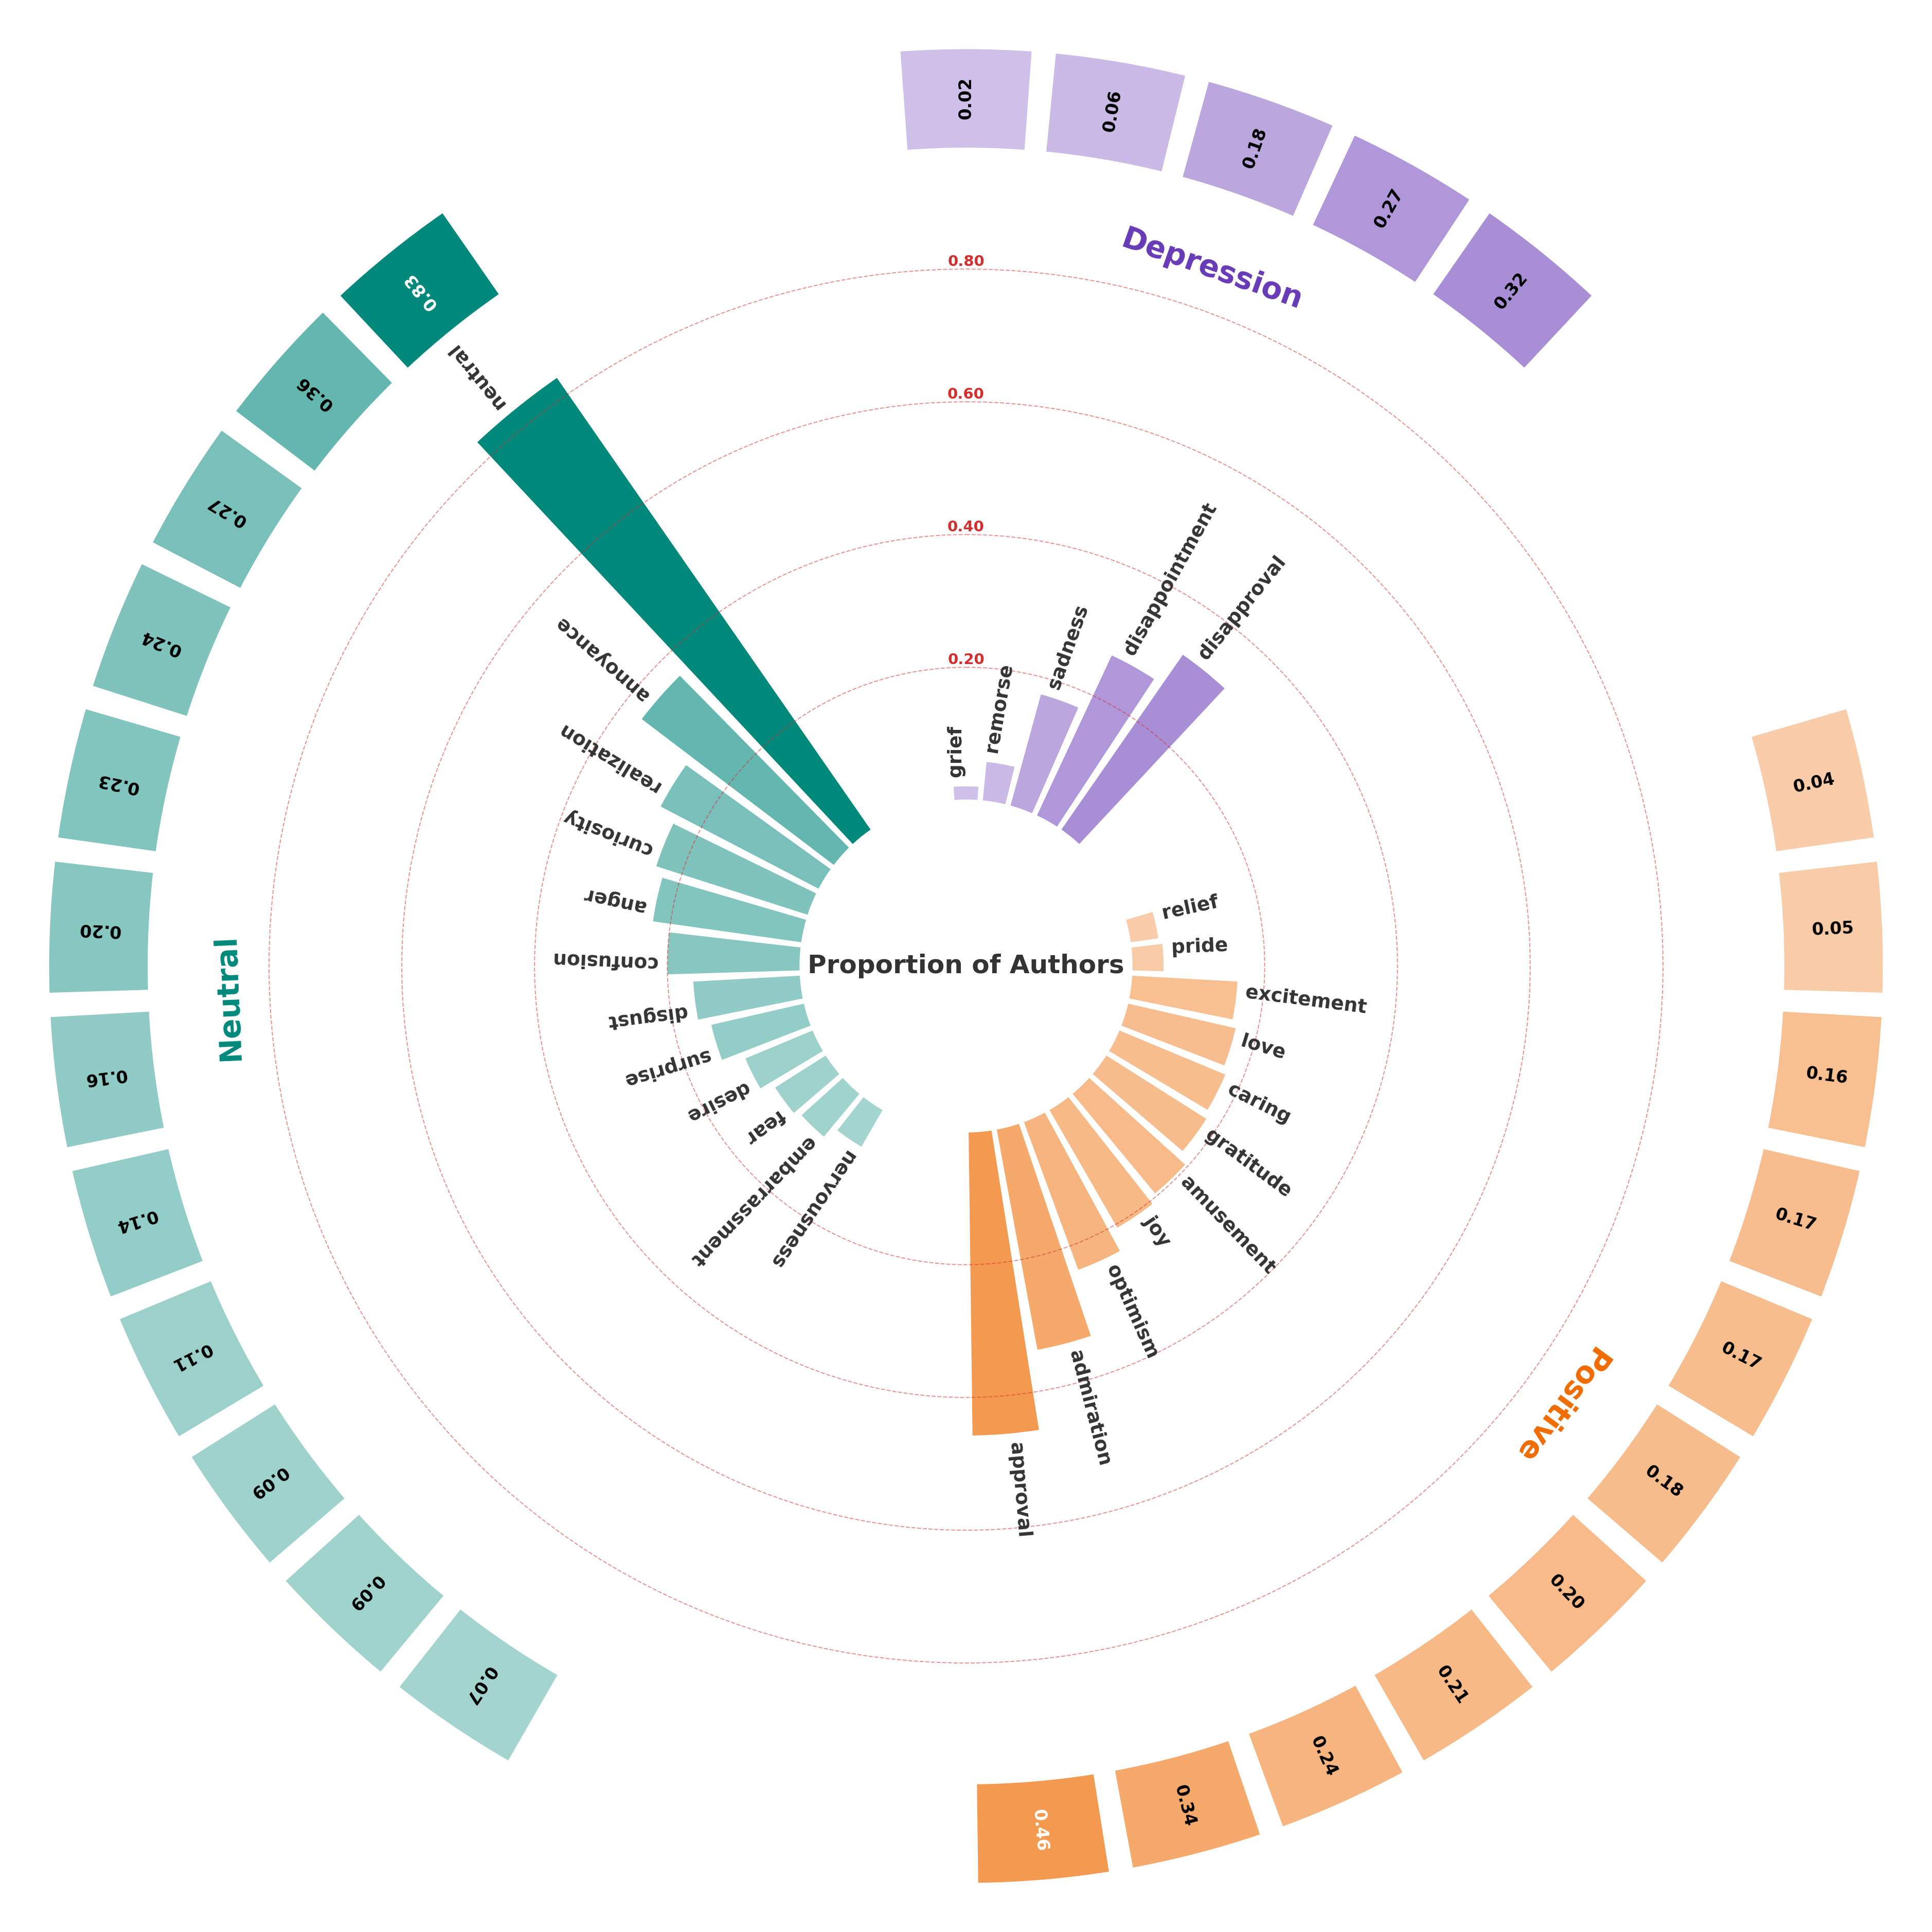

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

# ================= 1. 数据硬编码 =================
data_rows = {
    'label': [
        'grief', 'remorse', 'sadness', 'disappointment', 'disapproval', 
        'relief', 'pride', 'excitement', 'love', 'caring', 'gratitude', 
        'amusement', 'joy', 'optimism', 'admiration', 'approval', 
        'nervousness', 'embarrassment', 'fear', 'desire', 'surprise', 
        'disgust', 'confusion', 'anger', 'curiosity', 'realization', 
        'annoyance', 'neutral'
    ],
    'value': [
        0.0214203010420687, 0.059629486684677734, 0.17522192203782325, 0.2676572751833269, 0.3222693940563489, 
        0.04341952913932844, 0.048436896950984173, 0.16036279428791972, 0.16769587032033964, 0.17425704361250482, 
        0.17985333847935162, 0.19625627170976456, 0.20609803164801235, 0.2387109224237746, 0.33886530297182554, 
        0.458124276341181, 0.0652257815515245, 0.08529525279814744, 0.09166345040524894, 0.11115399459668082, 
        0.1445387881126978, 0.16229255113855653, 0.20069471246622925, 0.2271323813199537, 0.24102663064453878, 
        0.2697800077190274, 0.3647240447703589, 0.8299884214588962
    ],
    'group': [
        'Depression', 'Depression', 'Depression', 'Depression', 'Depression', 
        'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 
        'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 
        'Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral', 
        'Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral'
    ]
}
df_plot = pd.DataFrame(data_rows)
max_val = df_plot['value'].max()

# ================= 2. 布局参数修正 =================
data_dir = r"D:\SCI\DAIC-WOZ\code"
inner_radius = 0.25
label_padding = 0.002 # 情绪文字对齐终极修正
text_va = 'bottom'   

# **外圈增大**
outer_ring_width = 0.15 # 增加外圈宽度
new_group_gap = 0.15 # 保持间隔

# **组名向内移动**
# 半径计算
bar_top_radius_max = inner_radius + max_val
emotion_label_radius_base = bar_top_radius_max + label_padding 
# 组名位置：减小乘数，使其更靠近内侧
group_label_radius = emotion_label_radius_base + (new_group_gap * 0.2) 
outer_ring_start = emotion_label_radius_base + new_group_gap 
outer_ring_center = outer_ring_start + outer_ring_width / 2
plot_max_radius = outer_ring_start + outer_ring_width

# --- 角度计算 ---
total_bars = len(df_plot)
groups_def = df_plot['group'].unique()
gap_size = 3
total_slots = total_bars + (len(groups_def) * gap_size)
theta = np.linspace(0, 2 * np.pi, total_slots, endpoint=False)
bar_width = (2 * np.pi) / total_slots * 0.85 
base_colors = {'Depression': '#673AB7', 'Positive': '#EF6C00', 'Neutral': '#00897B'}


# ================= 3. 绘制极坐标图 =================
print("正在绘制图表...")

plt.figure(figsize=(16, 16), dpi=300)
ax = plt.subplot(111, polar=True)

current_idx = 0
group_labels_pos = []

for group_name in groups_def:
    group_df = df_plot[df_plot['group'] == group_name]
    n_bars = len(group_df)
    indices = range(current_idx, current_idx + n_bars)
    angles = theta[indices]
    
    base_c = mcolors.to_rgb(base_colors[group_name])
    vals = group_df['value'].values
    
    bar_colors = []
    outer_colors = []
    for v in vals:
        intensity = 0.3 + 0.7 * (v / max_val)
        c = list(base_c) + [intensity]
        bar_colors.append(c)
        outer_colors.append(c)

    # 1. 绘制柱子 & 2. 绘制外圈数值环
    ax.bar(angles, group_df['value'], width=bar_width, bottom=inner_radius,
           color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.bar(angles, outer_ring_width, width=bar_width, bottom=outer_ring_start,
           color=outer_colors, edgecolor='white', linewidth=0.5)

    # 3. 标签绘制
    for angle, label, val in zip(angles, group_df['label'], group_df['value']):
        rot_deg = np.rad2deg(angle)
        
        # --- 情绪文字动态半径修正 ---
        emotion_label_radius_dynamic = inner_radius + val + label_padding

        # --- **情绪/数值旋转逻辑** (切向对齐) ---
        text_rot = rot_deg - 90
        
        # 翻转逻辑：下半圆 (90 < rot_deg < 270)，使文字正向朝上
        #if 90 < rot_deg < 270:
        #    text_rot_flipped = text_rot + 180
        #    text_ha = 'right' 
        #else:
        text_rot_flipped = text_rot
        text_ha = 'left' 

        # 最终旋转角度：使用 Matplotlib 视觉修正的负号
        text_rot_final = -text_rot_flipped
        text_rot_final %= 360 

        # === A. 情绪名称 - 切向对齐 ===
        ax.text(angle, emotion_label_radius_dynamic, f" {label} ", 
                ha=text_ha, va=text_va, rotation=text_rot_final,
                fontsize=9, fontweight='bold', color='#333333',
                rotation_mode='anchor') 

        # === B. 数值 - 切向对齐 ===
        val_str = f"{val:.2f}"
        text_color = 'white' if (val / max_val) > 0.5 else 'black' 
        
        ax.text(angle, outer_ring_center, val_str,
                ha='center', va='center', rotation=text_rot_final,
                fontsize=8, fontweight='bold', color=text_color,
                rotation_mode='anchor')

    # --- 4. 记录组名位置 ---
    mid_angle = (angles[0] + angles[-1]) / 2
    rot_deg_group = np.rad2deg(mid_angle)
    
    # **组名切向对齐 (垂直于半径) 回归**
    group_rot = rot_deg_group# - 180
    
    #if 90 < rot_deg_group < 270:
    #    group_rot += 180
        
    group_rot_final = -group_rot # **实现垂直于半径**
    group_rot_final %= 360
        
    group_labels_pos.append({'name': group_name, 'angle': mid_angle, 'rotation': group_rot_final})

    current_idx += n_bars + gap_size


# --- 5. 绘制组名 (使用切向旋转) ---
for group_info in group_labels_pos:
    ax.text(group_info['angle'], group_label_radius, group_info['name'], 
            ha='center', va='center', rotation=group_info['rotation'],
            fontsize=14, fontweight='bold', color=base_colors[group_info['name']],
            rotation_mode='anchor') 


# ================= 6. 样式调整 =================
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1) # 顺时针
ax.spines['polar'].set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.grid(False)

ax.set_ylim(0, plot_max_radius + 0.05)

# --- 绘制红色同心圆网格 ---
grid_interval = 0.2 
grids = np.arange(grid_interval, max_val + 0.01, grid_interval)

for g in grids:
    r_pos = inner_radius + g
    if r_pos < bar_top_radius_max + 0.01:
        ax.plot(np.linspace(0, 2*np.pi, 200), [r_pos]*200, 
                color='#D32F2F', linestyle='--', linewidth=0.5, alpha=0.5)
        # 保持刻度标签不变
        ax.text(0, r_pos, f'{g:.2f}', color='#D32F2F', fontsize=7, 
                ha='center', va='bottom', fontweight='bold')

# **--- 径向轴标签 (纵轴标签) ---**

ax.text(0, 0, 'Proportion of Authors', 
        ha='center', va='center', 
        fontsize=12, fontweight='bold', color='#333333')


# 保存
save_path = os.path.join(data_dir, 'polar_emotion_chart_final_v30_axis_label.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"最终图表已保存至: {save_path}")
plt.show()